Task 1 : Autoencoder using Fashion MNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0441 - val_loss: 0.0228
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0203 - val_loss: 0.0186
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0173 - val_loss: 0.0163
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0155 - val_loss: 0.0152
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0143 - val_loss: 0.0140
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


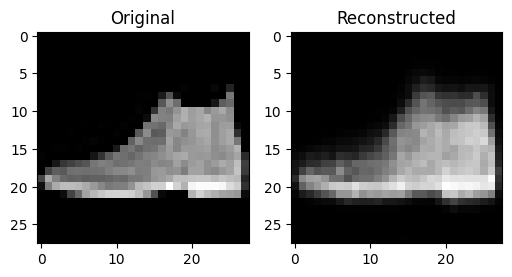

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Flatten images
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat = x_test.reshape((len(x_test), 784))

# Encoder
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Autoencoder
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

# Train
autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)

# Reconstruction
reconstructed = autoencoder.predict(x_test_flat)

# Display original and reconstructed
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(x_test[0], cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(reconstructed[0].reshape(28,28), cmap='gray')
plt.title("Reconstructed")

plt.show()

### Task 2 : Autoencoder with Binary Crossentropy

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2915 - val_loss: 0.2864
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2834 - val_loss: 0.2849
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2819 - val_loss: 0.2834
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2805 - val_loss: 0.2821
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2793 - val_loss: 0.2810
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


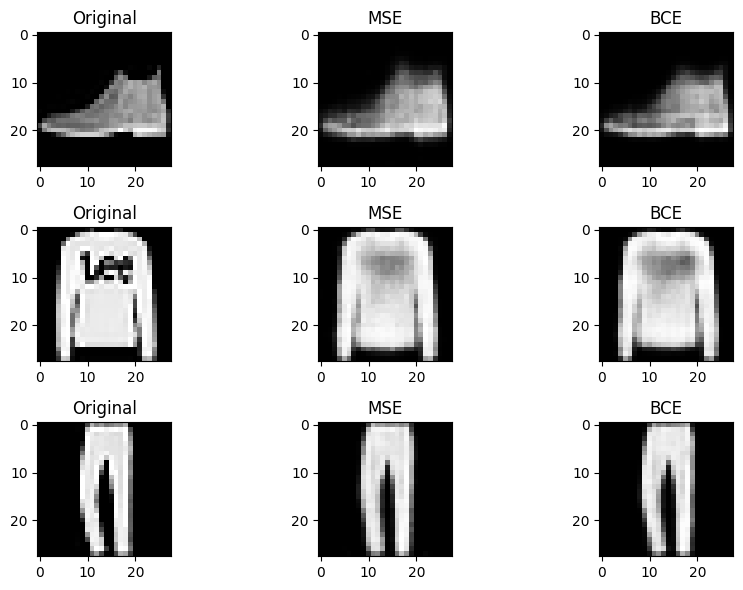

In [2]:
autoencoder_bce = Model(input_img, decoded)

autoencoder_bce.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder_bce.fit(
    x_train_flat,
    x_train_flat,
    epochs=5,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat)
)

reconstructed_bce = autoencoder_bce.predict(x_test_flat)

# Compare 3 images
plt.figure(figsize=(9,6))

for i in range(3):

    plt.subplot(3,3,i*3+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")

    plt.subplot(3,3,i*3+2)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.title("MSE")

    plt.subplot(3,3,i*3+3)
    plt.imshow(reconstructed_bce[i].reshape(28,28), cmap='gray')
    plt.title("BCE")

plt.tight_layout()
plt.show()

### Task 3: Image Denoising using Autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


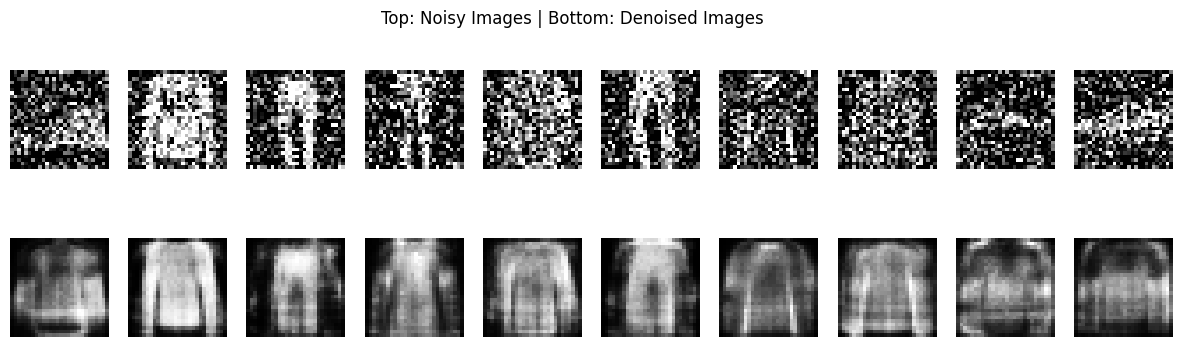

In [3]:
# Add noise
noise_factor = 0.5

x_test_noisy = x_test_flat + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test_flat.shape
)

x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Denoise
denoised = autoencoder.predict(x_test_noisy)

# Display 10 examples
plt.figure(figsize=(15,4))

for i in range(10):

    plt.subplot(2,10,i+1)
    plt.imshow(
        x_test_noisy[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(
        denoised[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

plt.suptitle("Top: Noisy Images | Bottom: Denoised Images")
plt.show()

### Task 4: Variational Autoencoder (VAE)

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

latent_dim = 2

encoder_inputs = keras.Input(shape=(784,))

x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=(tf.shape(z_mean)[0], latent_dim)
    )

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

In [16]:
latent_inputs = keras.Input(shape=(latent_dim,))

x = layers.Dense(256, activation="relu")(latent_inputs)

decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

In [17]:
class VAE(keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=-1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

In [21]:
vae = VAE(
    encoder,
    decoder
)

vae.compile(
    optimizer="adam"
)

vae.fit(
    x_train_flat,
    epochs=25,
    batch_size=256
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 4.6235 - loss: 36.8966 - reconstruction_loss: 32.2731
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 4.8114 - loss: 37.3710 - reconstruction_loss: 32.5596
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 4.7707 - loss: 37.7108 - reconstruction_loss: 32.9401
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - kl_loss: 4.7136 - loss: 36.1295 - reconstruction_loss: 31.4159
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.9869 - loss: 36.3898 - reconstruction_loss: 31.4029
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.8365 - loss: 36.5691 - reconstruction_loss: 31.7326
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.8960 - loss: 36.1782 - reconstruction_loss: 31.2822
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.7605 - loss: 36.4942 - reconstruction_loss: 31.7337
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


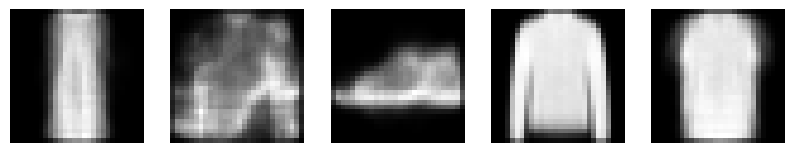

In [22]:
import matplotlib.pyplot as plt
import numpy as np

random_points = np.random.normal(
    size=(5, latent_dim)
)

generated_images = decoder.predict(
    random_points
)

plt.figure(figsize=(10,2))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        generated_images[i].reshape(28,28),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

### **Task 5: KL-Divergence Explanation**

Prompt Used

Explain in simple words what KL-divergence loss does in a Variational Autoencoder (VAE) and why it is necessary.

ChatGPT Response

KL-divergence (Kullback-Leibler Divergence) is a loss term used in Variational Autoencoders to keep the learned latent space organized and smooth. During training, the encoder generates a probability distribution for each image instead of a single point. KL-divergence measures how different this learned distribution is from a standard normal distribution (mean = 0, variance = 1).

Without KL-divergence, the latent space could become irregular, making it difficult to generate new images. By forcing latent vectors to follow a normal distribution, similar images stay close together in latent space and random sampling becomes meaningful.

This allows the VAE to generate completely new images by sampling random points from the latent space and passing them through the decoder. Therefore, KL-divergence is essential for creating a structured latent space and enabling image generation.